# TP 5.1 : Classification avec R

## 1. Données `body` allégées

Nous considérons une nouvelles fois les données `body`.

In [10]:
data_body <- read.table("data/body.csv", header=TRUE, sep=";", dec=",", row.names=1)
head(data_body)
nrow(data_body)

,T.epaule,T.poitrine,T.taille,Masse,Taille
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
H1,106.2,89.5,71.5,65.6,174.0
H2,110.5,97.0,79.0,71.8,175.3
H3,115.1,97.5,83.2,80.7,193.5
H4,104.5,97.0,77.8,72.6,186.5
H5,107.5,97.5,80.0,78.8,187.2
H6,119.8,99.9,82.5,74.8,181.5


[1] 20

### 1.1 Classification ascendante hiérarchique

Grâce à la fonction `dist()`, il est possible de calculer les distances euclidiennes entre toutes les paires d'individus.

In [22]:
distances <- dist(data_body)

<div class="alert alert-block alert-success">
    Quelle est la longueur de l'objet créé ? À quoi correspond cette valeur ?
</div>

In [13]:
length(distances)
sum(1:nrow(data_body)-1)

[1] 190

[1] 190

La fonction `hclust()` permet de mettre en oeuvre une classification ascendante hiérarchique à partir de l'objet `distances` et le dendrogramme correspondant s'affiche avec `plot()`.

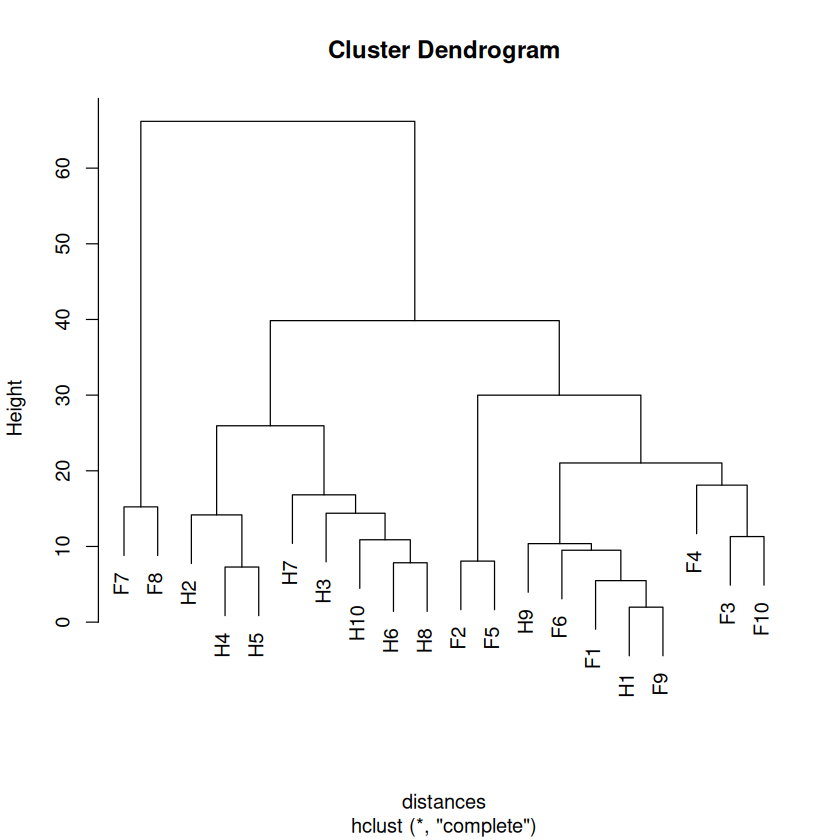

In [17]:
cah_body <- hclust(distances)
par(bg = 'white')
plot(cah_body)

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Quel critère d'agglomération est utilisé par défaut par la fonction <code>hclust()</code> ?</li>
        <li>Mettre en oeuvre une classification ascendante hiérarchique en utilisant le critère de Ward comme critère d'agglomération.</li>
        <li>Représenter le dendrogramme associé aux résultats de cette classification.</li>
        <li>En utilisant <code>cah_body&dollar;height</code>, proposer un nombre de groupes raisonnable pour répartir les individus ?</li>
        <li>Utiliser la fonction <code>cutree()</code> avec le nombre de groupes souhaités pour associer chaque individu à un groupe. Les groupes peuvent être visualisés sur le dendrogramme en utilisant la fonction <code>rect.hclust()</code> et l'option <code>border=</code> pour les couleurs.<br>
            <center><img src="img/cah_body.png"></center></li>
        <li>Calculer une ACP des données <code>body</code> et représenter les individus dans le plan principal en donnant une couleur identique aux individus d'un même groupe de votre classification.<br>
            <center><img src="img/cah_acp_body.png"></center></li>
    </ol>
</div>

Question 1 :
liaison complète 

ChatGPT a dit :

En classification hiérarchique ascendante (CHA), la liaison complète (complete linkage en anglais) est une des façons de définir la distance entre deux groupes (clusters) lors des fusions successives.

Principe

À chaque étape :

 - On a plusieurs groupes (au départ chaque individu est seul).

 - Pour savoir quels deux groupes fusionner, on calcule la distance entre groupes comme la plus grande distance entre deux points, un dans chaque groupe.

 - On fusionne les deux groupes dont cette distance maximale est la plus petite.


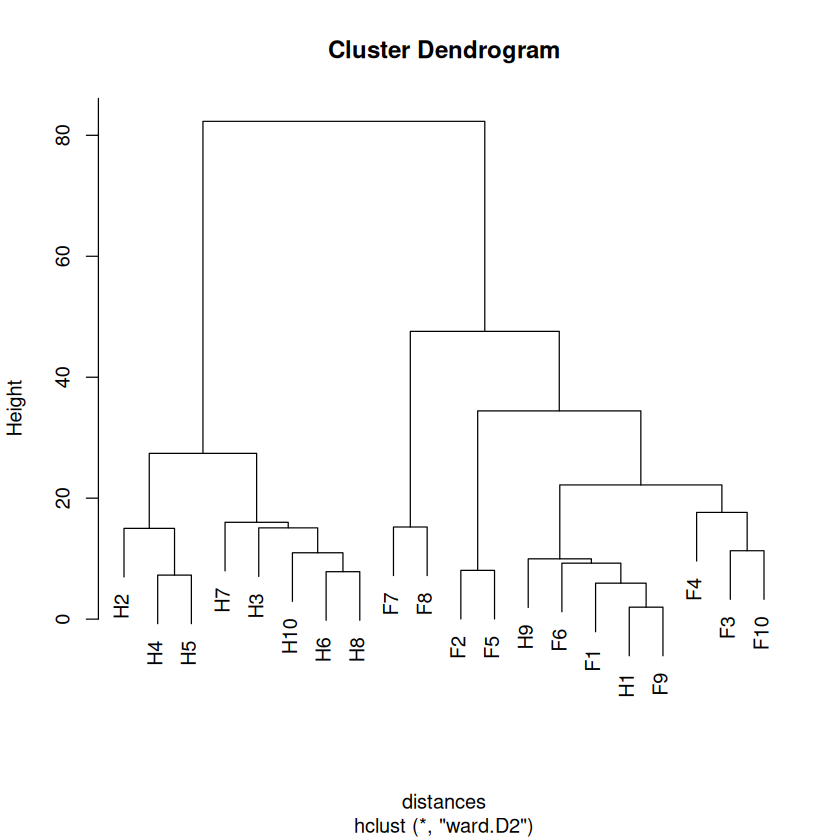

In [ ]:
#2 et #3

cah_body_ward <- hclust(distances,method = 'ward.D2')
par(bg = 'white')
plot(cah_body_ward)

$height[i] = distance (ou augmentation de variance pour Ward) au moment où le iᵉ fusion est effectuée.
Ce vecteur est croissant, car chaque fusion regroupe des clusters plus éloignés.

[1]  1.974842  5.946988  7.281483  7.846655  8.064118  9.254368  9.966845
 [8] 10.971022 11.310172 15.008220 15.090284 15.233516 16.014181 17.648040
[15] 22.189438 27.413397 34.435527 47.582581 82.310091

k optimal :  4

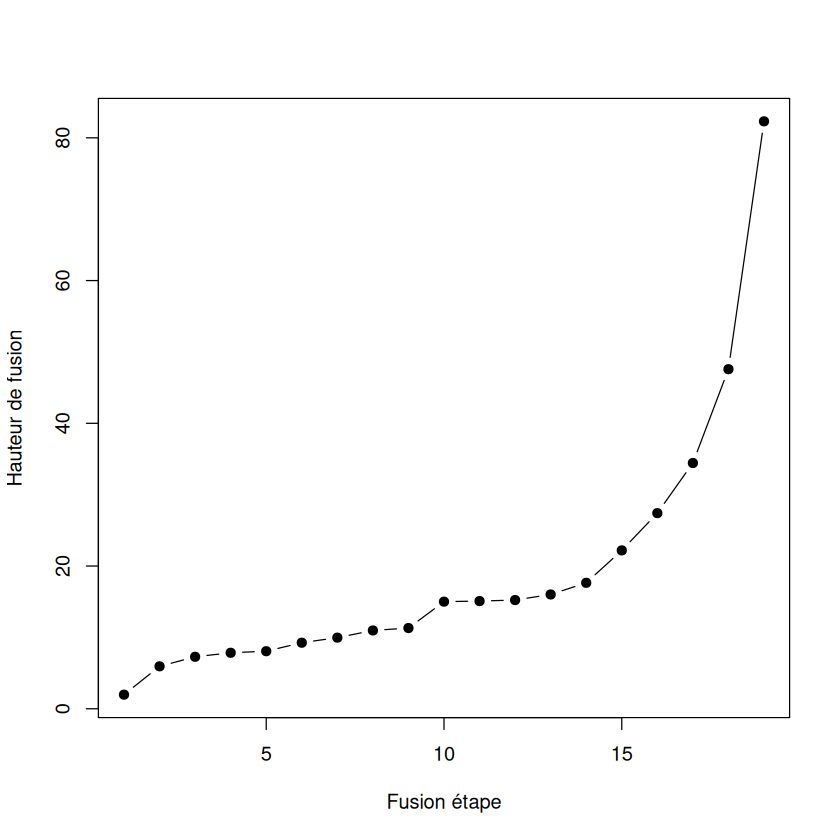

In [64]:
#4 

cah_body_ward$height

par(bg = 'white')
plot(cah_body_ward$height, type = "b", pch = 19,
     ylab = "Hauteur de fusion",
     xlab = "Fusion étape")


cat("k optimal : ", 4)


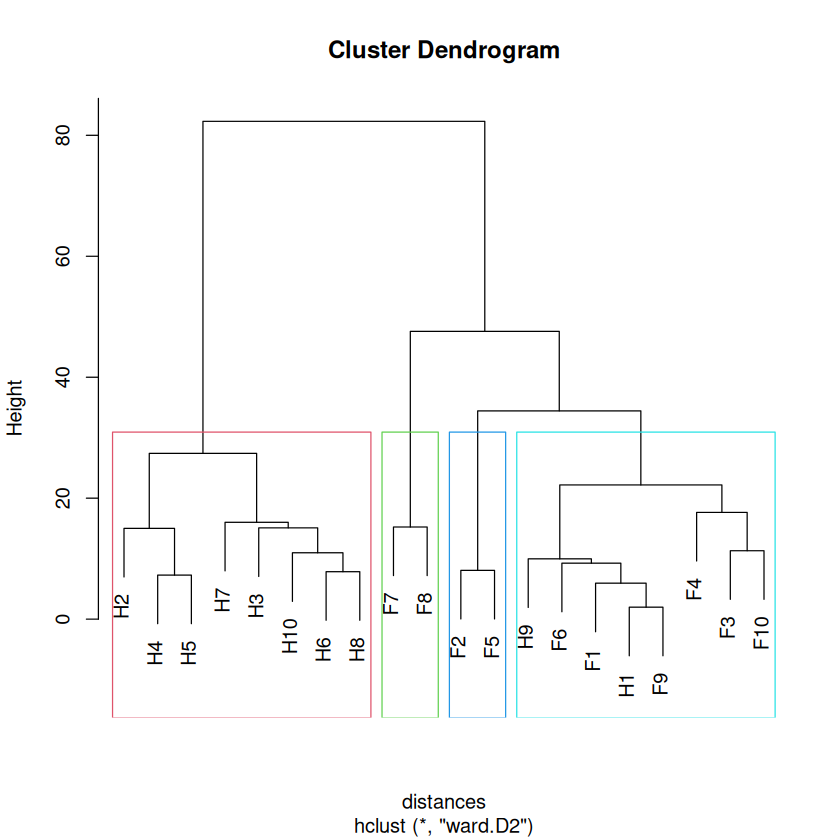

In [69]:
#5 

groups_ward <- cutree(cah_body_ward, k = 4)

par(bg = 'white')
plot(cah_body_ward)
rect.hclust(cah_body_ward, k = 4, border = 2:6)


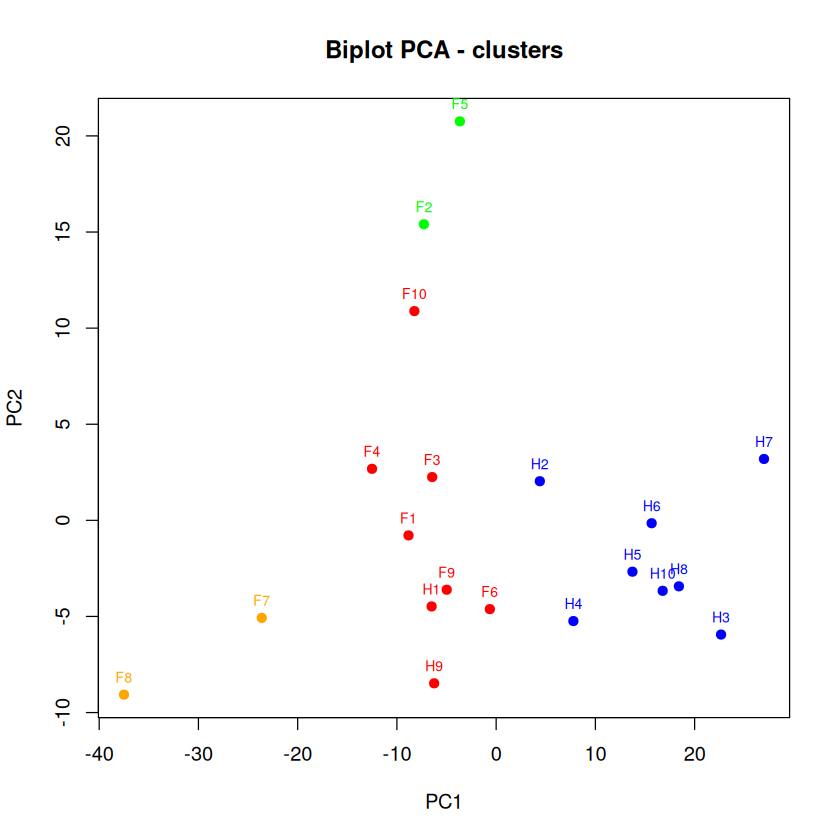

In [81]:
#6 

acp_body <- prcomp(data_body)

par(bg = 'white')




# Coordonnées des points
points_pca <- acp_body$x[, 1:2]

# Coordonnées des flèches (variables)
arrows_pca <- acp_body$rotation[, 1:2]

# Couleurs des points
cols <- c("red", "blue", "green", "orange")
point_colors <- cols[groups_ward]

plot(points_pca, col = point_colors, pch = 19,
     xlab = "PC1", ylab = "PC2", main = "Biplot PCA - clusters")

obs_names <- rownames(data_body)
text(points_pca, labels = obs_names, col = point_colors, pos = 3, cex = 0.7)




### 1.2 K-means

Pour réaliser un algorithme K-means, il est possible d'utiliser la fonction `kmeans()` avec l'option `centers=` pour définir un nombre entier de groupes.

In [20]:
# Exemple de K-means à 4 groupes
kmeans_body_1 <- kmeans(data_body, centers=4)
cat("Groupes des individus pour le premier K-means :\n")
print(kmeans_body_1$cluster)


# Un autre exemple de K-means à 4 groupes
kmeans_body_2 <- kmeans(data_body, centers=4)
cat("Groupes des individus pour le second K-means :\n")
print(kmeans_body_2$cluster)

Groupes des individus pour le premier K-means :
 H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  3   3   1   1   1   1   1   1   3   1   3   4   3   3   4   3   2   2   3   4 
Groupes des individus pour le second K-means :
 H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  4   4   3   3   3   3   3   3   4   3   4   1   4   4   1   4   2   2   4   1 


<div class="alert alert-block alert-success">
    Expliquer pourquoi les résultats obtenus sont différents.
</div>

Résultats différents car à l'initialisation kmeans() choisit les centres aléatoirement

Il est possible de construire la table de contingence qui croise les effectifs des 4 groupes obtenus dans les 2 cas avec la fonction `table()`.

In [31]:

table(kmeans_body_1$cluster, kmeans_body_2$cluster, dnn=c("kmeans1", "kmeans2"))

       kmeans2
kmeans1 1 2 3 4
      1 0 0 7 0
      2 0 2 0 0
      3 0 0 0 8
      4 3 0 0 0

<div class="alert alert-block alert-success">
    Croiser également l'un des résultats obtenus avec les groupes issus de la classification ascendante hiérarchique.
</div>

In [33]:
groups_cah_body <- cutree(cah_body, k = 4)  # coupe l'arbre en 4 groupes
groups_cah_body

table(kmeans_body_1$cluster, groups_cah_body, dnn=c("kmeans1", "cah_body"))

H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  1   2   2   2   2   2   2   2   1   2   1   3   1   1   3   1   4   4   1   1

       cah_body
kmeans1 1 2 3 4
      1 0 7 0 0
      2 0 0 0 2
      3 7 1 0 0
      4 1 0 2 0

Afin de pallier l'aspect aléatoire de l'algorithme K-means et de stabiliser le résultat d'une classification ascendante hiérarchique, nous pouvons imposer les centres initiaux du K-means comme étant ceux donnés par les groupes de la CAH.

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Calculer les barycentres des classes issues de la classification hiérarchique ascendante et stocker ces résultats en ligne dans une matrice à 5 colonnes.</li>
        <li>Passer cette matrice à l'option <code>centers=</code> de la fonction <code>kmeans()</code>. Est-ce que le résultat est encore aléatoire ?</li>
        <li>Comparer les résultats de cette classification avec ceux de la classification ascendante hiérarchique sous forme d'une table puis sous forme graphique dans le plan principal.</li>
    </ol>
</div>

In [36]:
# 1 barycentres de la CHA
#barycentre : vecteur de dimension égale aux nombres de variables 

barycentres <- aggregate(data_body, by = list(cluster = groups_cah_body), FUN = mean)
barycentres


cluster,T.epaule,T.poitrine,T.taille,Masse,Taille
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,105.6125,92.1375,72.65,66.2500,171.0125
2,115.1000,98.9750,79.85,78.1375,184.5625
3,102.1000,94.7500,82.80,76.1500,158.7500
4,95.6000,82.7000,60.70,52.0500,162.5500


In [50]:
#2 

centers_matrix <- as.matrix(barycentres[, -1])

kmeans_body_barycentre <- kmeans(data_body, centers = centers_matrix)

kmeans_body_barycentre$cluster


H1  H2  H3  H4  H5  H6  H7  H8  H9 H10  F1  F2  F3  F4  F5  F6  F7  F8  F9 F10 
  1   1   2   2   2   2   2   2   1   2   1   3   1   1   3   1   4   4   1   3

In [ ]:
#3

table(kmeans_body_barycentre$cluster, groups_cah_body, dnn=c("kmeans1", "cah_body"))

       cah_body
kmeans1 1 2 3 4
      1 7 1 0 0
      2 0 7 0 0
      3 1 0 2 0
      4 0 0 0 2

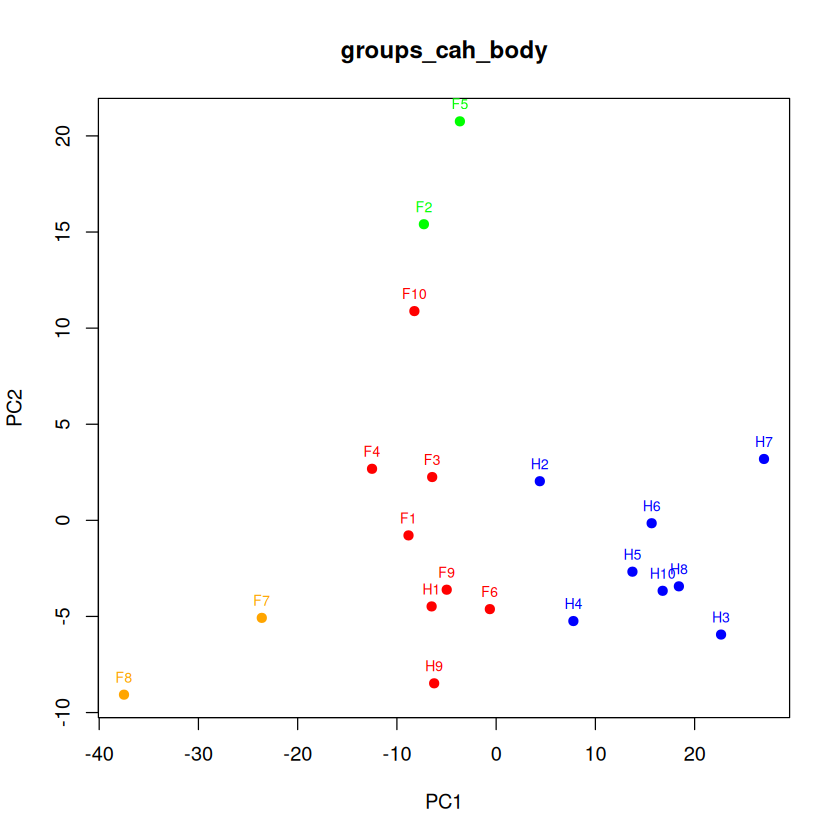

In [84]:
#3 suite 

acp_body <- prcomp(data_body)

par(bg = 'white')


# Coordonnées des points
points_pca <- acp_body$x[, 1:2]

# Coordonnées des flèches (variables)
arrows_pca <- acp_body$rotation[, 1:2]

# Couleurs des points
cols <- c("red", "blue", "green", "orange")
point_colors <- cols[groups_cah_body]

plot(points_pca, col = point_colors, pch = 19,
     xlab = "PC1", ylab = "PC2", main = "groups_cah_body")

obs_names <- rownames(data_body)
text(points_pca, labels = obs_names, col = point_colors, pos = 3, cex = 0.7)


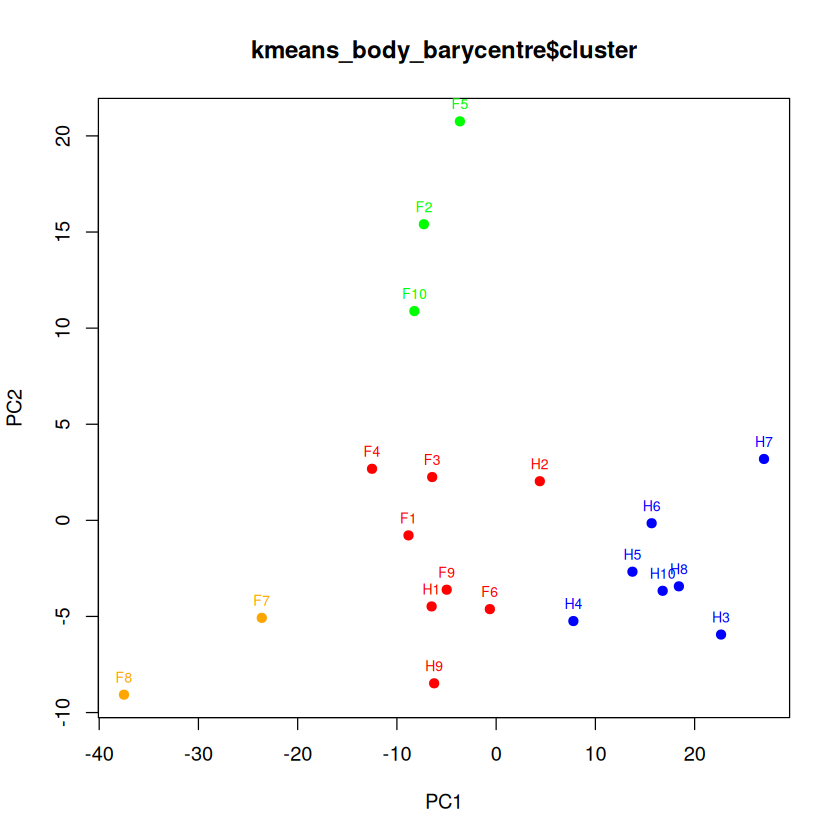

In [85]:

acp_body <- prcomp(data_body)

par(bg = 'white')


# Coordonnées des points
points_pca <- acp_body$x[, 1:2]

# Coordonnées des flèches (variables)
arrows_pca <- acp_body$rotation[, 1:2]

# Couleurs des points
cols <- c("red", "blue", "green", "orange")
point_colors <- cols[kmeans_body_barycentre$cluster]

plot(points_pca, col = point_colors, pch = 19,
     xlab = "PC1", ylab = "PC2", main = "kmeans_body_barycentre$cluster")

obs_names <- rownames(data_body)
text(points_pca, labels = obs_names, col = point_colors, pos = 3, cex = 0.7)

## 2. Données `body` complètes

Les données sont consituées de 24 variables quantitatives (diamètres, circonférence, âge, taille, poids, ...) mesurées chez 507 individus hommes et femmes (le sexe étant précisé dans la variable `gender`).

In [112]:
data_body_full <- read.table("data/data-body.csv", sep=";", dec=",", header=TRUE)
head(data_body_full)

,biacromial,pelvic.breadth,bitrochanteric,chest.depth,chest.diam,elbow.diam,wrist.diam,knee.diam,ankle.diam,shoulder.girth,⋯,bicep.girth,forearm.girth,knee.girth,calf.girth,ankle.girth,wrist.girth,age,weight,height,gender
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,42.9,26.0,31.5,17.7,28.0,13.1,10.4,18.8,14.1,106.2,⋯,32.5,26.0,34.5,36.5,23.5,16.5,21.0,65.6,174.0,M
2,43.7,28.5,33.5,16.9,30.8,14.0,11.8,20.6,15.1,110.5,⋯,34.4,28.0,36.5,37.5,24.5,17.0,23.0,71.8,175.3,M
3,40.1,28.2,33.3,20.9,31.7,13.9,10.9,19.7,14.1,115.1,⋯,33.4,28.8,37.0,37.3,21.9,16.9,28.0,80.7,193.5,M
4,44.3,29.9,34.0,18.4,28.2,13.9,11.2,20.9,15.0,104.5,⋯,31.0,26.2,37.0,34.8,23.0,16.6,23.0,72.6,186.5,M
5,42.5,29.9,34.0,21.5,29.4,15.2,11.6,20.7,14.9,107.5,⋯,32.0,28.4,37.7,38.6,24.4,18.0,22.0,78.8,187.2,M
6,43.3,27.0,31.5,19.6,31.3,14.0,11.5,18.8,13.9,119.8,⋯,33.0,28.0,36.6,36.1,23.5,16.9,20.6,74.8,181.5,M


<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Procéder à une classification ascendante hiérarchique (distance euclidienne et critère de Ward) sur les individus et représenter le dendrogramme associé.</li>
        <li>En combien de groupes classeriez-vous les individus ?</li>
        <li>Comparer les groupes de la classification à la variable <code>gender</code> à l'aide d'une table.</li>
        <li>Proposer plusieurs façons de caractériser chacun des groupes de la classification (individus moyens par groupe, ACP, ...).</li>
    </ol>
</div>

Warning message in dist(data_body_full):
“NAs introduits lors de la conversion automatique”


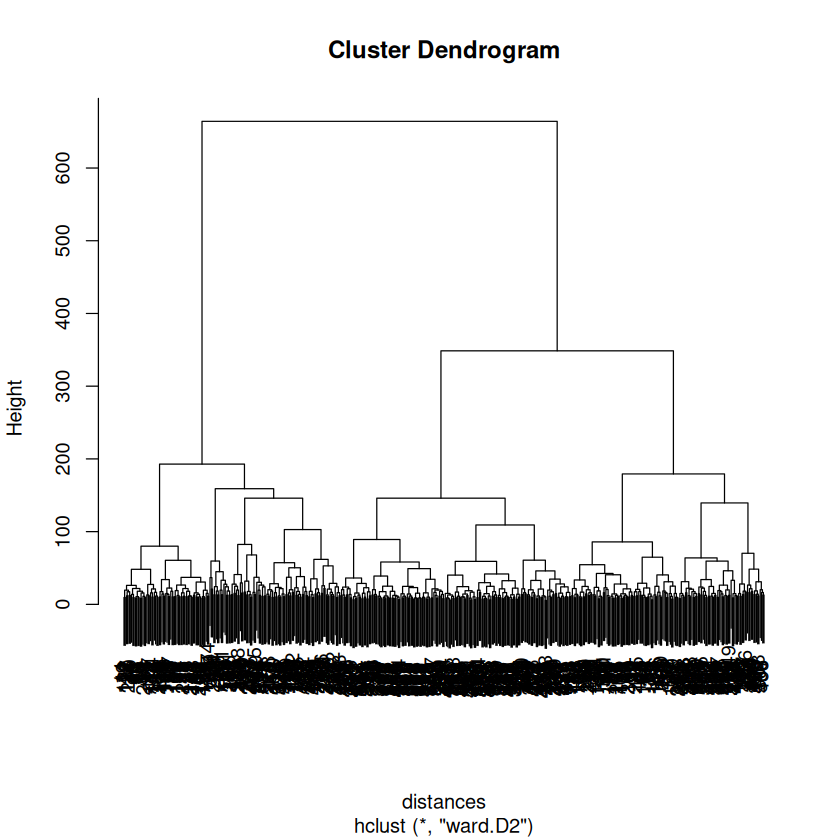

In [ ]:
#1

distances <- dist(data_body_full)
cah_body <- hclust(distances, method = 'ward.D2')

par(bg = 'white')
plot(cah_body)


k optimal :  4

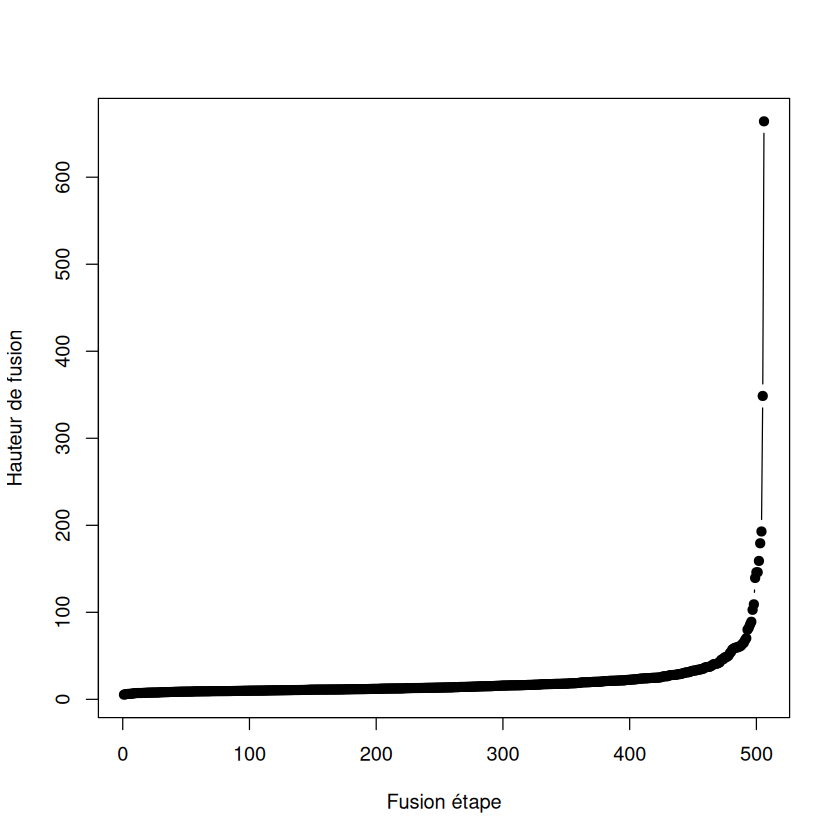

In [93]:
#2


par(bg = 'white')
plot(cah_body$height, type = "b", pch = 19,
     ylab = "Hauteur de fusion",
     xlab = "Fusion étape")


cat("k optimal : ", 4)

In [113]:
#3 


groups_cah_body <- cutree(cah_body, k = 4) 


table(data_body_full$gender,groups_cah_body,dnn=c("gender", "cah_body"))

      cah_body
gender   1   2   3   4
     F  61   0  24 175
     M  92  68  80   7

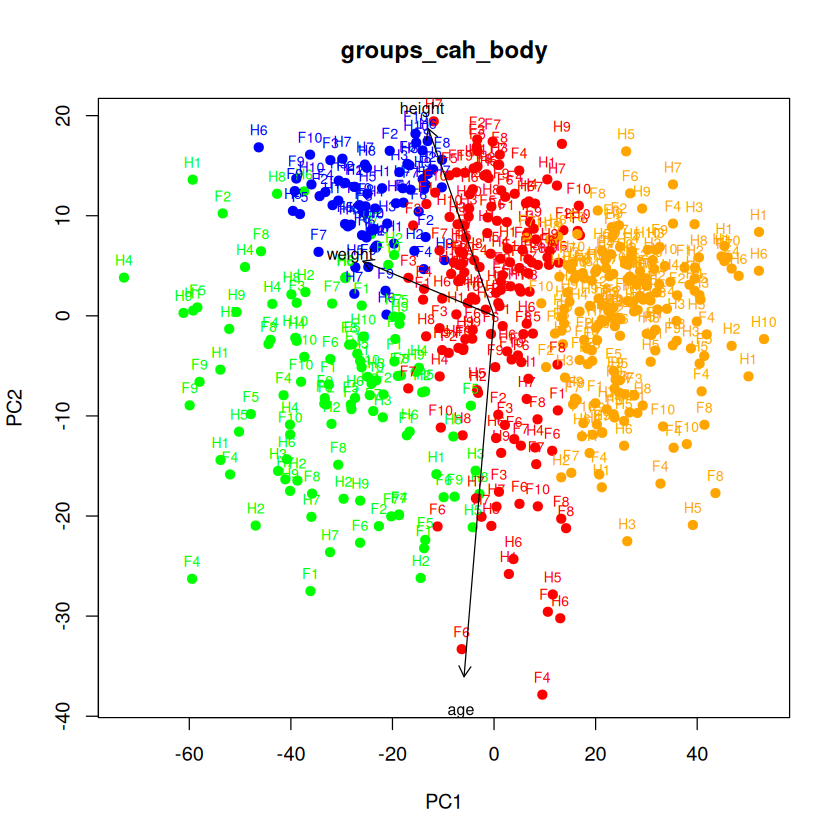

In [124]:
#4


data_body_num <- data_body_full[, sapply(data_body_full, is.numeric)]

acp_body <- prcomp(data_body_num)

par(bg = 'white')

# Coordonnées des points
points_pca <- acp_body$x[, 1:2]

# Coordonnées des flèches (variables)
arrows_pca <- acp_body$rotation[, 1:2]

# Couleurs des points
cols <- c("red", "blue", "green", "orange")
point_colors <- cols[groups_cah_body]

plot(points_pca, col = point_colors, pch = 19,
     xlab = "PC1", ylab = "PC2", main = "groups_cah_body")

obs_names <- rownames(data_body)
text(points_pca, labels = obs_names, col = point_colors, pos = 3, cex = 0.7)

vars_selected <- c("age", "height", "weight")

arrows_selected <- arrows_pca[vars_selected, ]  # extraire uniquement ces lignes

mult <- 50  # facteur pour agrandir les vecteurs

# Ajouter les flèches
arrows(0, 0, arrows_selected[,1]*mult, arrows_selected[,2]*mult, length = 0.1, col = "black")

# Ajouter les labels
text(arrows_selected[,1]*mult*1.1, arrows_selected[,2]*mult*1.1,
     labels = rownames(arrows_selected), col = "black", cex = 0.8)



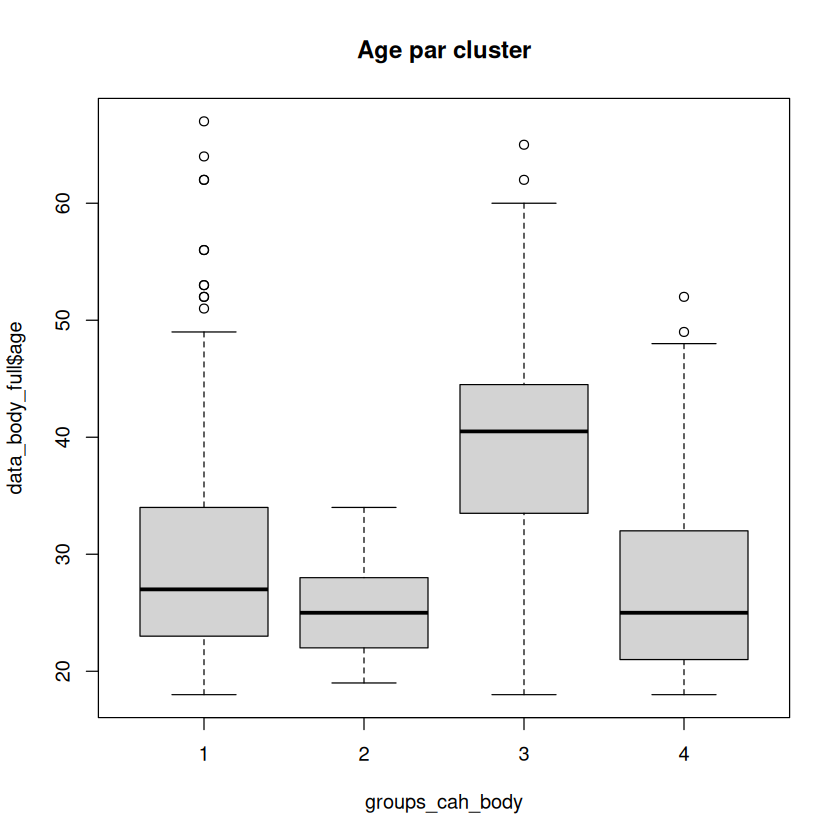

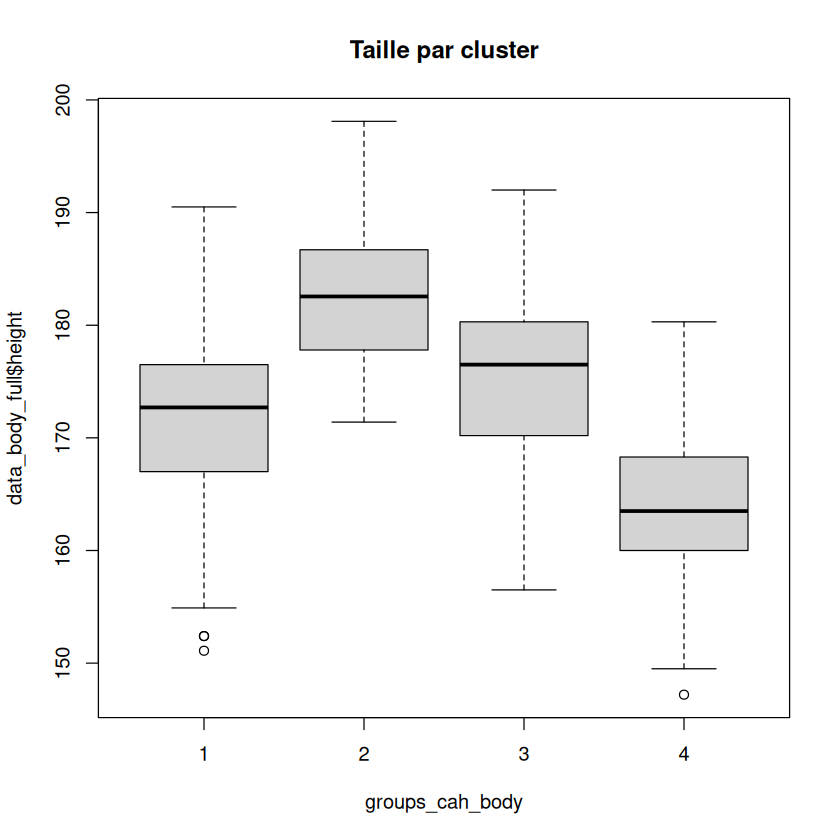

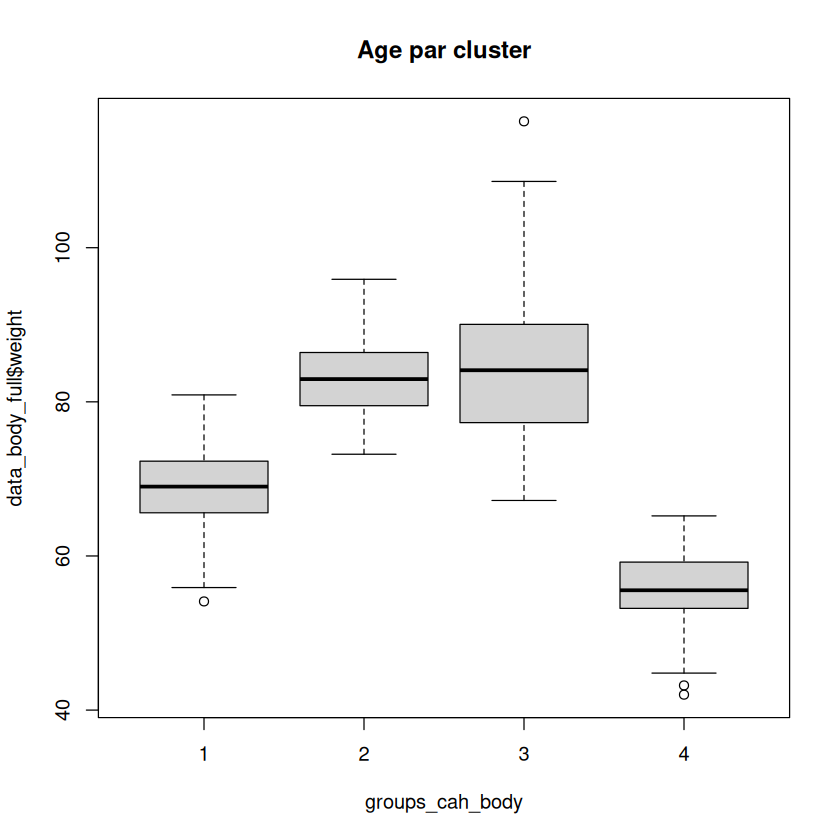

In [118]:

par(bg = "white")

boxplot(data_body_full$age ~ groups_cah_body, main = "Age par cluster")
boxplot(data_body_full$height ~ groups_cah_body, main = "Taille par cluster")
boxplot(data_body_full$weight ~ groups_cah_body, main = "Age par cluster")



